In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path


In [ ]:
# Load data
# Collectri is in ressource folder
collectri = pd.read_csv('resources/collectri.tsv', sep = '\t')

# This is the preprocessed anndata object.
adata_raw = sc.read_h5ad('netmap/data/blood/reprocessed/bd-rhap-rep1.h5ad')
experiment_name = 'bd-rhap-rep1-X'

# The dummy anndata object
output_dir = f"netmap/case_studies/blood/{experiment_name}/"
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs,)

In [ ]:
output_dir = Path(op.join(output_dir, "grn"))


In [ ]:
# Load top 10% edges for data object
grn_adata = retrieve_top_edges(grn_adata, output_dir, percentage=0.1 )

In [7]:
adata_raw.layers['counts']

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 2990346 stored elements and shape (10925, 1176)>

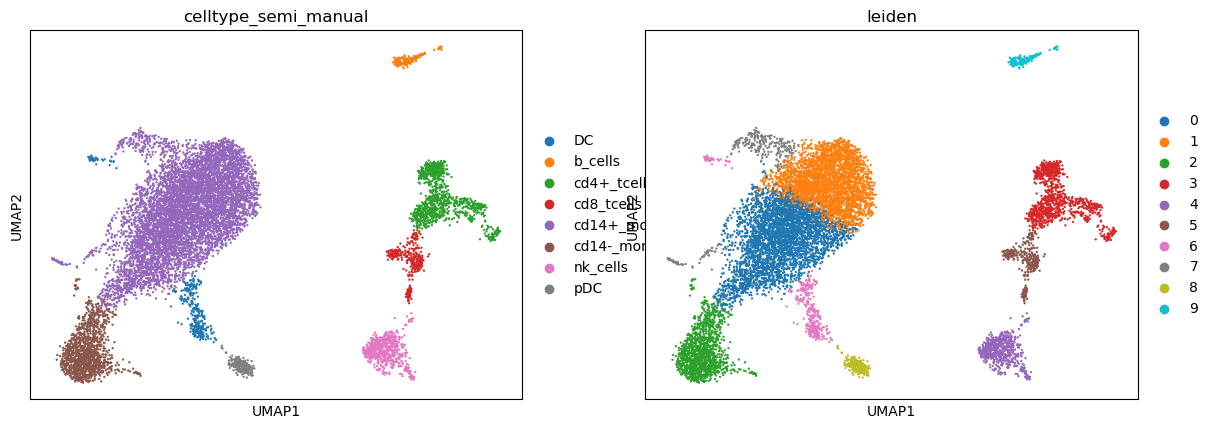

In [8]:
sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'leiden'])

In [ ]:

grn_adata.var = grn_adata.var.set_index('index')



In [ ]:
#Cluster GRN
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)


In [ ]:
# number of clusters should be equal to GEX anndata object (or smaller)
sc.tl.leiden(grn_adata, resolution=0.18)

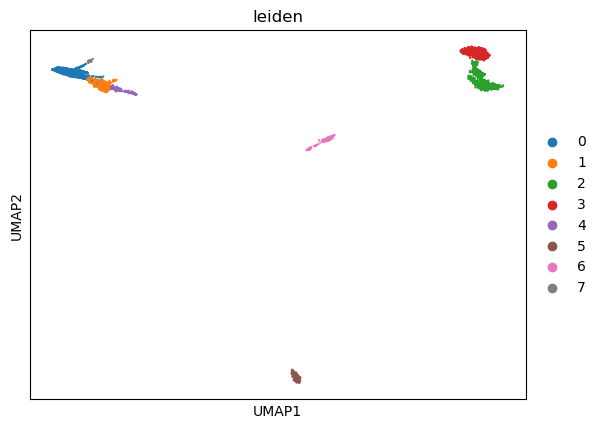

In [12]:
sc.pl.umap(grn_adata, color = 'leiden')

In [13]:
print("\nClustering Score Evaluation")
for col_grn in ["leiden"]:
    score = unify_group_labelling( adata_raw, grn_adata, 'celltype_semi_manual', col_grn)
    print(f"{col_grn} score: {score}")


Clustering Score Evaluation
leiden score: 0.9533180778032037


In [ ]:
# Transcfer the new labels to the GEX andata object.
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


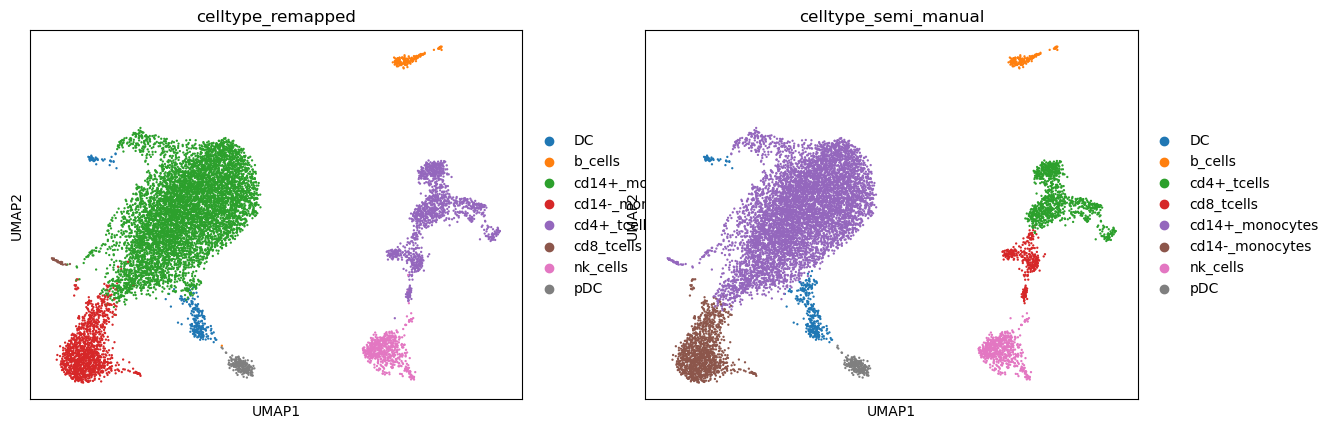

In [15]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual'])

In [ ]:
# Make a dummy GRN object
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')
grn_adata2.obs = grn_adata.obs

In [ ]:
# Select plausible edges based on the gene expression dataset
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
# Annotate edges which CAN be present in at least 0.3 based on gene expression mask
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.3)


In [ ]:
# Select edges which are candidates in at least one cluster
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
# Select plausible edges and load them into a new anndata obeject.
grn_adata3 = retrieve_edges_by_index(grn_adata2, output_dir, index_list)

In [20]:
grn_adata

AnnData object with n_obs × n_vars = 10925 × 138297
    obs: 'Unnamed: 0', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means'
    uns: 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
# Transfer the clustering the the new object
grn_adata3.obs = grn_adata2.obs
grn_adata3.obsm['X_pca'] = grn_adata.obsm['X_pca']
grn_adata3.obsm['X_umap'] = grn_adata.obsm['X_umap']

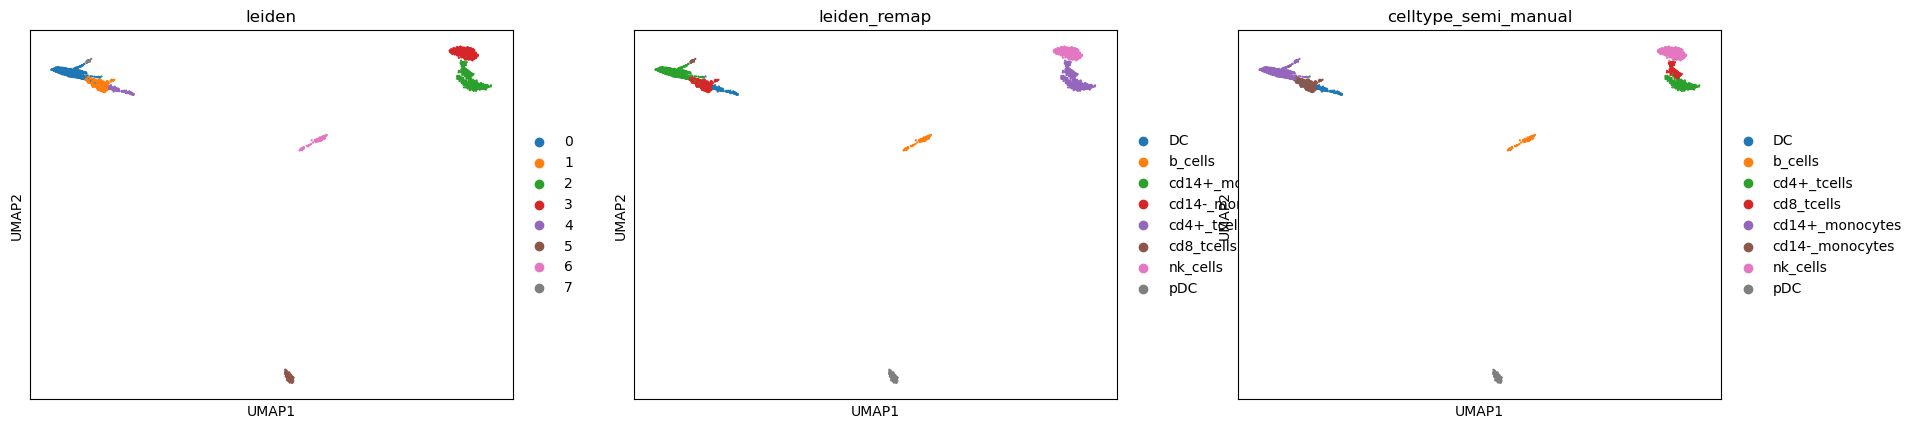

In [22]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'celltype_semi_manual'])

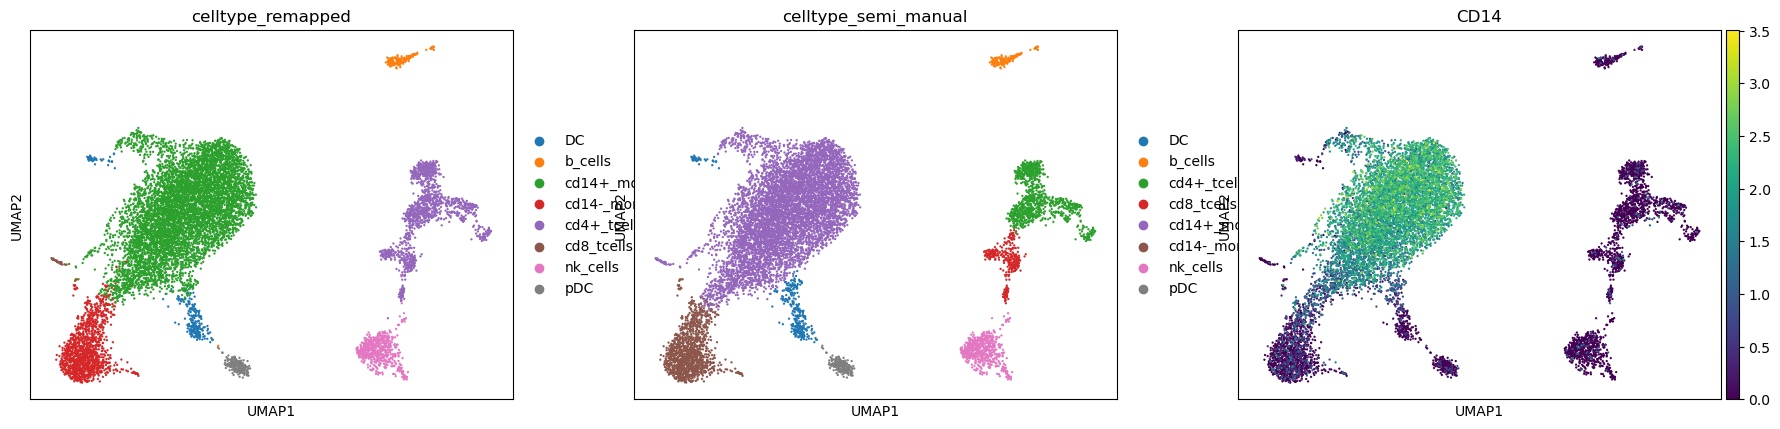

In [23]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual', 'CD14', ])

In [24]:
cross_tab = pd.crosstab(grn_adata3.obs['celltype_semi_manual'], grn_adata3.obs['leiden_remap'])

In [25]:
cross_tab

leiden_remap,DC,b_cells,cd14+_monocytes,cd14-_monocytes,cd4+_tcells,cd8_tcells,nk_cells,pDC
celltype_semi_manual,,,,,,,,
DC,275,0,67,0,0,0,0,0
b_cells,0,165,0,0,0,0,0,0
cd4+_tcells,0,0,0,0,964,0,0,0
cd8_tcells,0,0,0,0,344,0,3,0
cd14+_monocytes,3,0,6882,54,0,32,0,0
cd14-_monocytes,0,0,5,1307,0,0,0,0
nk_cells,0,0,0,0,1,0,612,0
pDC,0,1,0,0,0,0,0,210


In [ ]:
# This can be used to add is_source_collectri, is_target_collectri to annotate for each edge
# whether the source node of an edge is also in collectri
grn_adata3 = add_external_grn(grn_ad=grn_adata3,   external_grn=collectri,name_grn='collectri')

In [ ]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'celltype_semi_manual'
top_per_source = 30
min_reg_size = 3
sc.pp.scale(grn_adata3)
add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )
keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)

# If you want to only use specific genes as sources, e.g. TFs you can add a boolean mask where true
# indicates that the gene should be used as a source.
#keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, tf_column='is_source_collectri')



Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC


In [28]:
def aggregate_edges(selected_edges, grn_adata, key='unique') -> pd.DataFrame:
    """
    Filters gene signatures by cluster and computes UCell scores.

    Parameters
    ----------
    grn_adata : AnnData
        AnnData object containing GRN (gene regulatory network) information.
    adata : AnnData
        AnnData object containing gene expression counts in the 'counts' layer.

    Returns
    -------
    pd.DataFrame
        DataFrame with UCell scores merged with the 'spectral' cluster labels.
    """
    
    regulons = {}
    for ct in selected_edges[key]:
        print(ct)
        sign = selected_edges[key][ct]['edges'].groupby('source').apply(lambda x: (x['source'] + "_" + x['target']).tolist()).to_dict()
        for g in sign:
            regulons[f'{ct}_{g}'] = grn_adata[:, sign[g]].X.mean(axis = 1)
    regulons = pd.DataFrame(regulons)
    return regulons

In [31]:
regus = aggregate_edges(keep_edges, grn_adata3, key='unique')

DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8_tcells
nk_cells
pDC


In [32]:
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)

reguls = compute_signatures_UCell_scores(adata=adata_raw, selected_edges=keep_edges, )


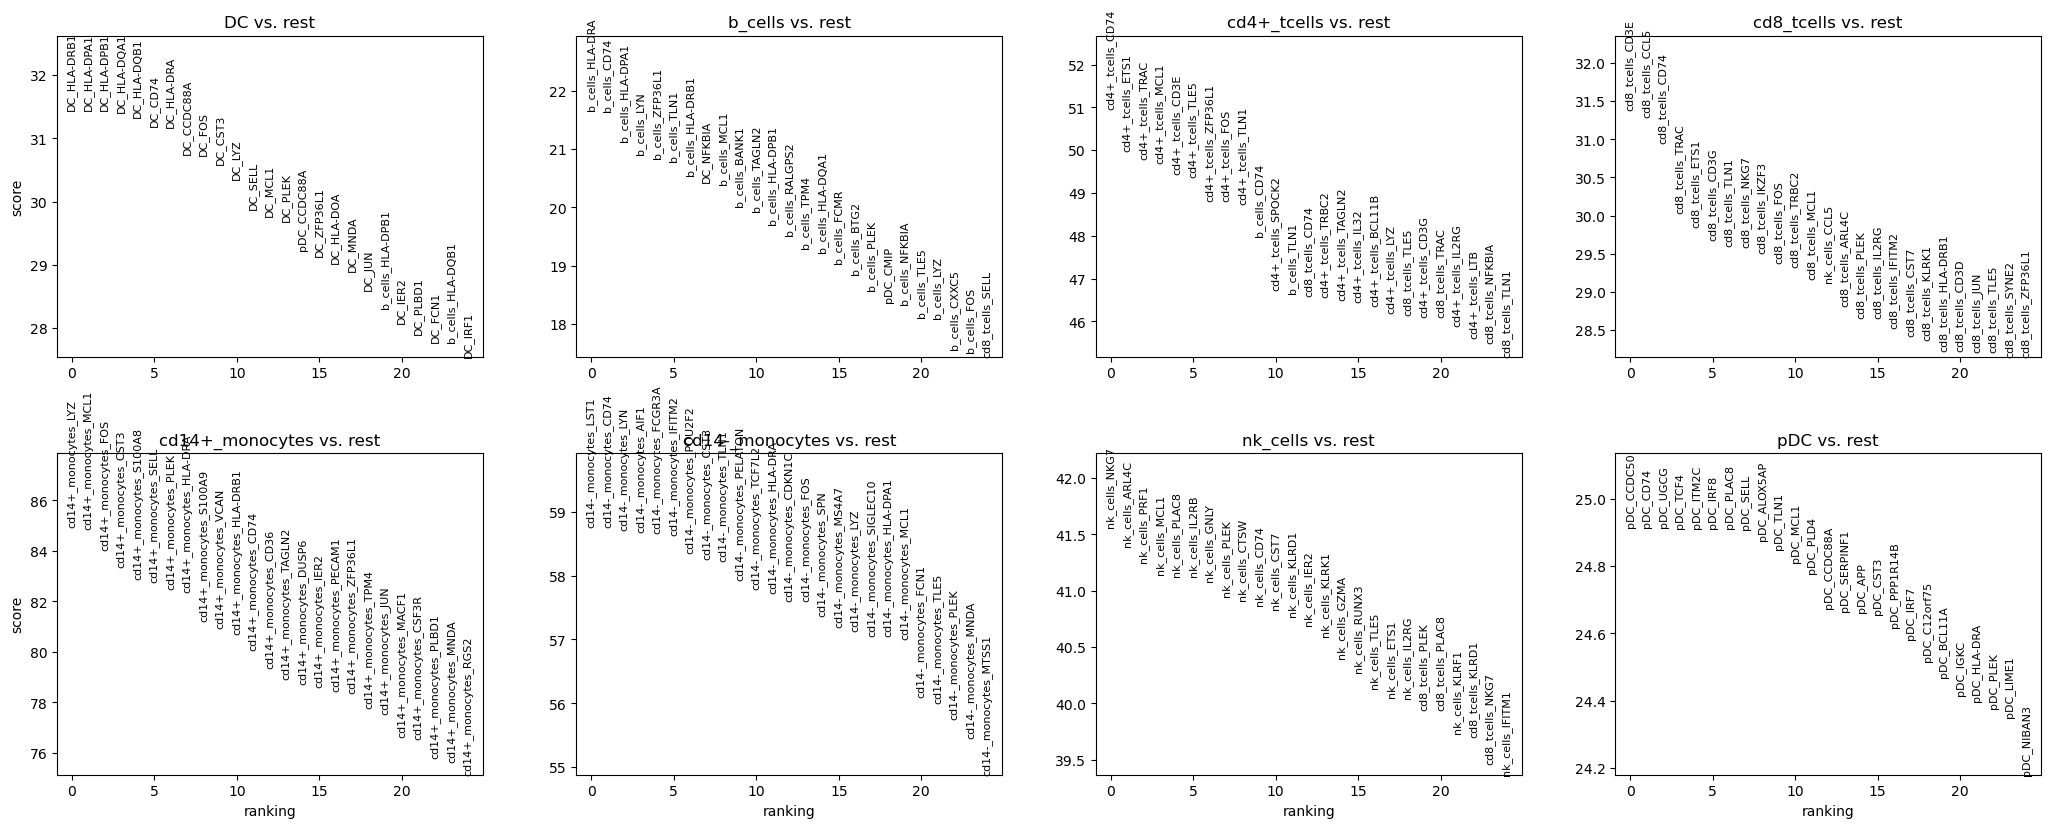

In [33]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [34]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column, n_genes=10)

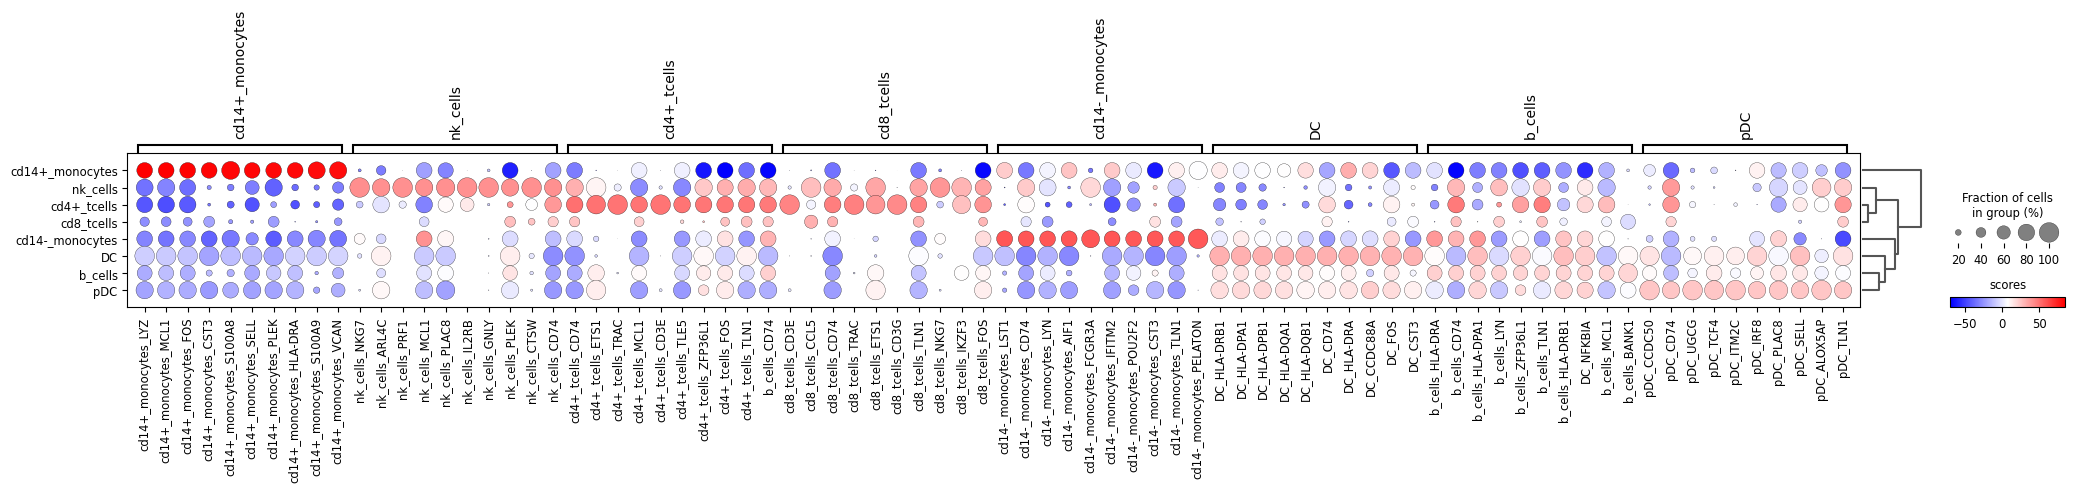

In [35]:
pp.show()

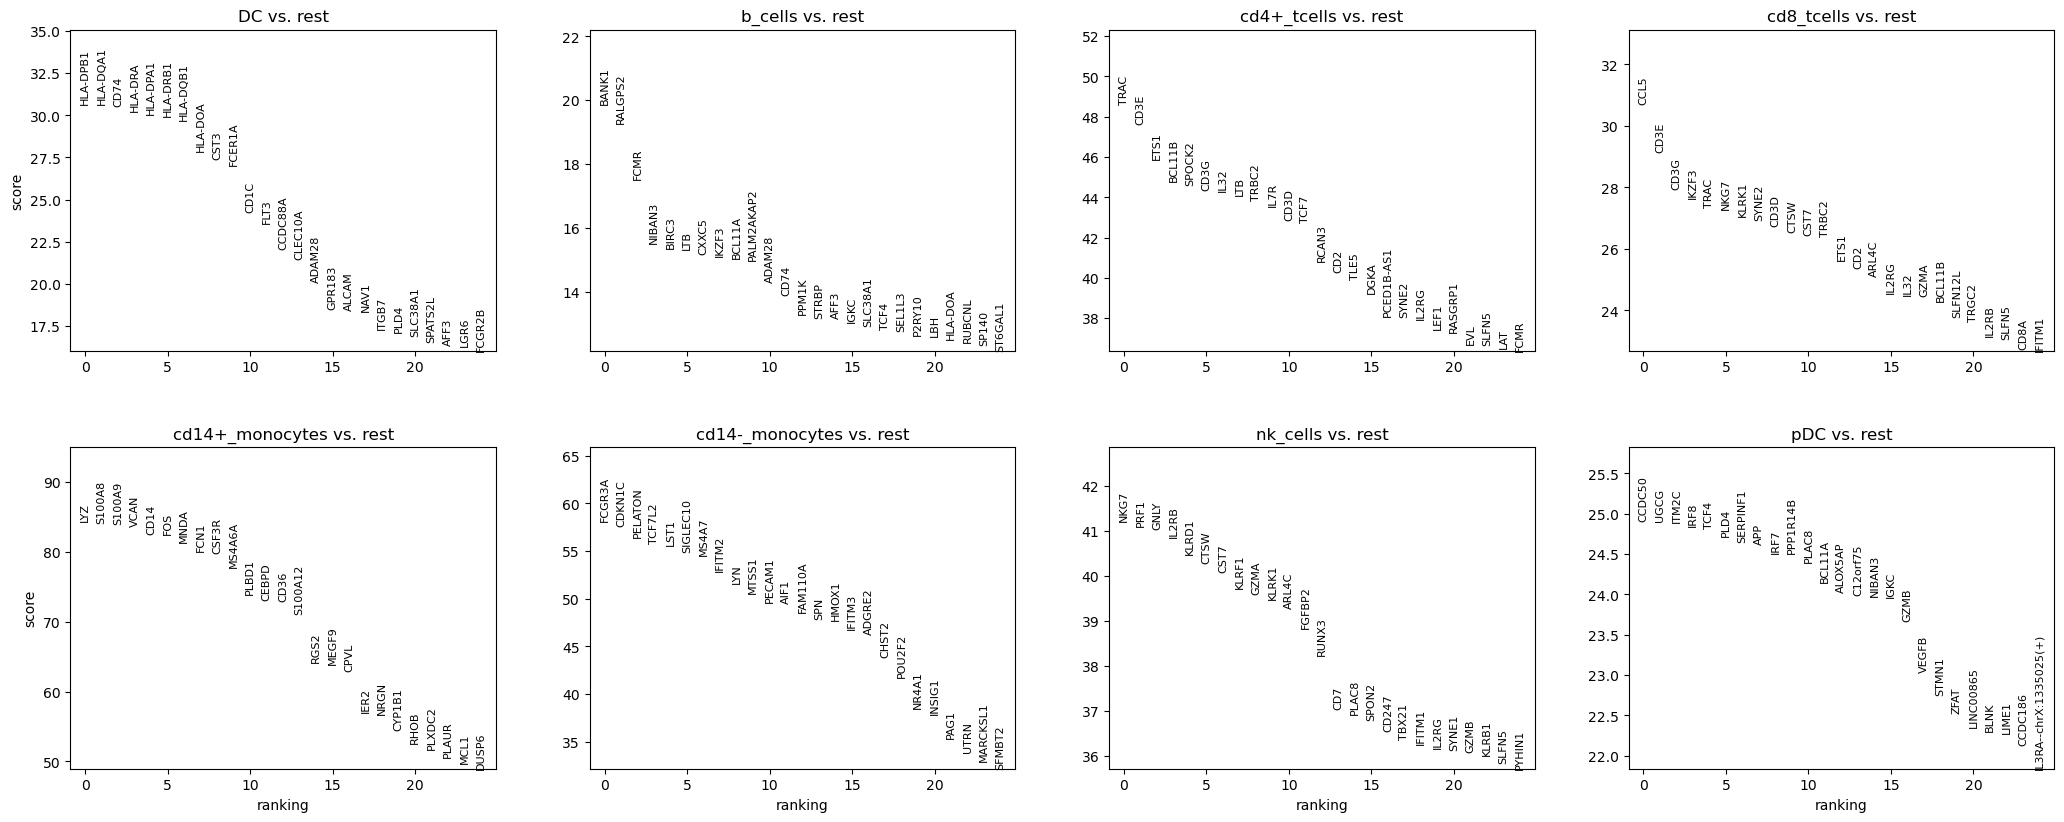

In [36]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(adata_raw, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(adata_raw, n_genes=25, sharey=False, key="wilcoxon")

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

ranked_terms = bcrank.celltype[0:100]

def calculate_raw_annotated_entropies(terms):
    raw_h = []
    first_occurrences = []
    seen = set()
    counts = Counter()
    
    for i, term in enumerate(terms, 1):
        if term not in seen:
            first_occurrences.append((i, term))
            seen.add(term)
        
        counts[term] += 1
        probs = [count / i for count in counts.values()]
        
        # Raw Shannon Entropy (H)
        h = -sum(p * np.log2(p) for p in probs if p > 0)
        raw_h.append(h)
            
    return raw_h, first_occurrences

# Compute values
raw, discoveries = calculate_raw_annotated_entropies(ranked_terms)
ranks = list(range(1, len(ranked_terms) + 1))

# 1. Plotting Raw Entropy Only
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Rank', fontsize=12)
ax1.set_ylabel('Raw Entropy (bits)',  fontsize=12)
# Replicating the distinct blue line style
ax1.plot(ranks, raw, linewidth=1.5, label='Raw Entropy (H)')
ax1.tick_params(axis='y' )
ax1.grid(True, linestyle='--', alpha=0.3)

# 2. Annotate Discoveries on the RAW line
for rank, term in discoveries:
    # Use raw entropy value for the y-position of the annotation
    y_pos = raw[rank-1]
    
    # Add a marker at the point
    ax1.scatter(rank, y_pos, color='black', s=30, zorder=5)
    
    # Add annotation text with an offset above the RAW line
    ax1.annotate(f'{term}', 
                 xy=(rank, y_pos), 
                 xytext=(rank, y_pos + 0.15), # Increased offset above RAW line
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black', lw=0.7),
                 ha='center', fontsize=9, zorder=6)

plt.title('Entropy vs. Rank')
plt.savefig('raw_entropy_annotated.png')

NameError: name 'bcrank' is not defined

In [ ]:
cellmarker = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/Cell_marker_Seq.csv', sep ='\t')

In [ ]:
metamarker = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/metamarkers.tsv', sep =',')

In [ ]:
metamarker

,Unnamed: 0,celltype,gene
0,0,Mixed,PF4
1,1,Mixed,CD44
2,2,Mixed,Gfi3
3,3,Mixed,Elane
4,4,Mixed,Klf1
...,...,...,...
982,982,Neutophils,CD16
983,983,Neutophils,CD101
984,984,Neutophils,CD11b
985,985,Neutophils,CD10


In [ ]:
grn_adata3.obs

,Unnamed: 0,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,n_genes,doublet_score,predicted_doublet,predicted_labels,majority_voting,conf_score,granular,leiden,celltype_semi_manual,leiden_remap
0,14150,4070,8.311644,17153.0,9.749987,33.032123,40.476885,49.594823,62.805340,2539.0,...,4070,0.027240,False,Monocytes,Monocytes,0.999381,Classical monocytes,0,cd14+_monocytes,cd14+_monocytes
1,40095,2874,7.963808,10292.0,9.239220,32.850758,40.040808,49.242130,64.438399,1976.0,...,2874,0.016636,False,Monocytes,Monocytes,0.999997,Non-classical monocytes,1,cd14-_monocytes,cd14-_monocytes
2,41585,3250,8.086718,11710.0,9.368284,32.826644,40.000000,48.403074,62.544833,1835.0,...,3250,0.039326,False,Monocytes,Monocytes,0.999697,Classical monocytes,0,cd14+_monocytes,cd14+_monocytes
3,50404,3817,8.247482,14549.0,9.585346,29.534676,36.930373,45.680115,59.687951,1865.0,...,3817,0.043515,False,Monocytes,Monocytes,0.999904,Non-classical monocytes,0,cd14+_monocytes,cd14+_monocytes
4,57895,2472,7.813187,6878.0,8.836228,27.595231,36.042454,45.594650,61.529514,742.0,...,2472,0.021364,False,T cells,T cells,0.999999,Regulatory T cells,2,cd4+_tcells,cd4+_tcells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10920,56585924,3330,8.111028,10944.0,9.300638,31.496711,39.501096,48.446637,62.079678,1460.0,...,3330,0.071514,False,Monocytes,Monocytes,0.999791,Classical monocytes,0,cd14+_monocytes,cd14+_monocytes
10921,56588762,2241,7.715124,5739.0,8.655214,32.671197,41.035024,49.607946,64.349190,982.0,...,2241,0.007257,False,T cells,T cells,0.999998,Tem/Effector helper T cells,2,cd4+_tcells,cd4+_tcells
10922,56590239,3188,8.067463,11599.0,9.358761,35.580654,43.943443,52.995948,66.212605,1776.0,...,3188,0.053711,False,Monocytes,Monocytes,0.998935,Classical monocytes,0,cd14+_monocytes,cd14+_monocytes
10923,56590950,3598,8.188411,13118.0,9.481817,28.075926,35.775271,45.532856,60.458911,1702.0,...,3598,0.012399,False,Monocytes,Monocytes,1.000000,Non-classical monocytes,1,cd14-_monocytes,cd14-_monocytes


In [ ]:
cm

,species,tissue_class,tissue_type,uberonongology_id,cancer_type,cell_type,cell_name,cellontology_id,marker,Symbol,GeneID,Genetype,Genename,UNIPROTID,technology_seq,marker_source,PMID,Title,journal,year
531,Human,Blood,Peripheral blood,UBERON_0005408,Normal,Normal cell,Megakaryocyte,CL_0000556,PF4,PF4,5196.0,protein_coding,platelet factor 4,P02776,10x Chromium,Experiment,30496484,Recovery and analysis of transcriptome subsets...,Nucleic acids research,2019
532,Human,Blood,Peripheral blood,UBERON_0005408,Normal,Normal cell,Peripheral immune cell,NaN,CD44,CD44,960.0,protein_coding,CD44 molecule (Indian blood group),P16070,CyTOF,Experiment,30559476,Human microglia regional heterogeneity and phe...,Nature neuroscience,2019
533,Human,Blood,Blood,UBERON_0000178,Normal,Normal cell,Classical monocyte,CL_0000860,HLA-DR,NaN,NaN,NaN,NaN,NaN,CyTOF,Experiment,30580568,Human Monocyte Heterogeneity as Revealed by Hi...,"Arteriosclerosis, thrombosis, and vascular bio...",2019
534,Human,Blood,Blood,UBERON_0000178,Normal,Normal cell,CD16+ monocyte,CL_0002397,CD61,ITGB3,3690.0,protein_coding,integrin subunit beta 3,P05106,CyTOF,Experiment,30580568,Human Monocyte Heterogeneity as Revealed by Hi...,"Arteriosclerosis, thrombosis, and vascular bio...",2019
535,Human,Blood,Blood,UBERON_0000178,Normal,Normal cell,CD16+ monocyte,CL_0002397,CD16,FCGR3A,2215.0,protein_coding,Fc fragment of IgG receptor IIIb,O75015,CyTOF,Experiment,30580568,Human Monocyte Heterogeneity as Revealed by Hi...,"Arteriosclerosis, thrombosis, and vascular bio...",2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10659,Human,Breast,Blood,UBERON_0000178,Breast Cancer,Cancer cell,Red blood cell (erythrocyte),CL_0000232,HBB,HBB,85344.0,protein_coding,keratin 89 pseudogene,NaN,Single-cell sequencing,Review,34965952,Differential Survival and Therapy Benefit of P...,Clinical cancer research : an official journal...,2021
10663,Human,Breast,Blood,UBERON_0000178,Breast Cancer,Cancer cell,Red blood cell (erythrocyte),CL_0000232,HBA2,HBA2,3040.0,protein_coding,hemoglobin subunit alpha 2,D1MGQ2,Single-cell sequencing,Review,34965952,Differential Survival and Therapy Benefit of P...,Clinical cancer research : an official journal...,2021
12637,Human,Eye,Blood,UBERON_0000178,Normal,Normal cell,Monocyte,CL_0000576,LYZ,LYZ,4069.0,protein_coding,lysozyme,B2R4C5,10x Chromium,Experiment,34488842,Analytic Pearson residuals for normalization o...,Genome biology,2021
12638,Human,Eye,Blood,UBERON_0000178,Normal,Normal cell,B cell,CL_0000236,Cd79a,NaN,NaN,NaN,NaN,NaN,10x Chromium,Experiment,34488842,Analytic Pearson residuals for normalization o...,Genome biology,2021


In [ ]:

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0


ct = 'cd8_tcells'
jacc_dfs = []
for ct in grn_adata3.obs.leiden_remap.unique():
    print(ct)
    bcrank = sc.get.rank_genes_groups_df(all_signatures, group= ct, key='wilcoxon')
    bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)
    topg = set(bcrank[0:20].gene)

    #cm = metamarker
    #marker_sets = cm.groupby('celltype')['gene'].apply(set).to_dict()

    cm = cellmarker[(cellmarker.tissue_type.isin(['Peripheral blood', 'Blood'])) & (cellmarker.species.isin(['Human']))]
    marker_sets = cm.groupby('cell_name')['marker'].apply(set).to_dict()
    names = list(marker_sets.keys())



    # Create similarity matrix
    n = len(names)
    sim_liste = {}

    for j in marker_sets:
        jac = jaccard_similarity(topg, marker_sets[j])
        sim_liste[j] = jac

    sim_liste = pd.DataFrame({'celltype': sim_liste.keys(), 'jaccard': sim_liste.values(), 'ct':ct})
    jacc_dfs.append(sim_liste)

cd14+_monocytes
cd14-_monocytes
cd4+_tcells
nk_cells
DC
pDC
b_cells
cd8_tcells


In [ ]:
jaccards = pd.concat(jacc_dfs)

In [ ]:
jaccards

,celltype,jaccard,ct
0,Abnormal myeloid cell,0.000000,cd14+_monocytes
1,Activated B cell,0.000000,cd14+_monocytes
2,Activated CD4+ T cell,0.029412,cd14+_monocytes
3,Activated CD8+ T cell,0.000000,cd14+_monocytes
4,Activated T cell,0.000000,cd14+_monocytes
...,...,...,...
190,Tissue resident memory T(TRM) cell,0.000000,cd8_tcells
191,Transitional B cell,0.000000,cd8_tcells
192,Transitional CD8+ T cell,0.000000,cd8_tcells
193,Tumor regulatory T cell,0.000000,cd8_tcells


In [ ]:
jaccards[jaccards.jaccard>0]

,celltype,jaccard,ct
2,Activated CD4+ T cell,0.029412,cd14+_monocytes
16,B cell,0.020833,cd14+_monocytes
21,CD14 monocyte,0.095238,cd14+_monocytes
22,CD14+ monocyte,0.064516,cd14+_monocytes
23,CD16 monocyte,0.047619,cd14+_monocytes
...,...,...,...
175,Regulatory T(Treg) cell,0.018868,cd8_tcells
180,T cell,0.058824,cd8_tcells
181,T cell large granular lymphocytic leukemia cell,0.090909,cd8_tcells
187,T helper(Th) cell,0.035714,cd8_tcells


<Figure size 1000x800 with 0 Axes>

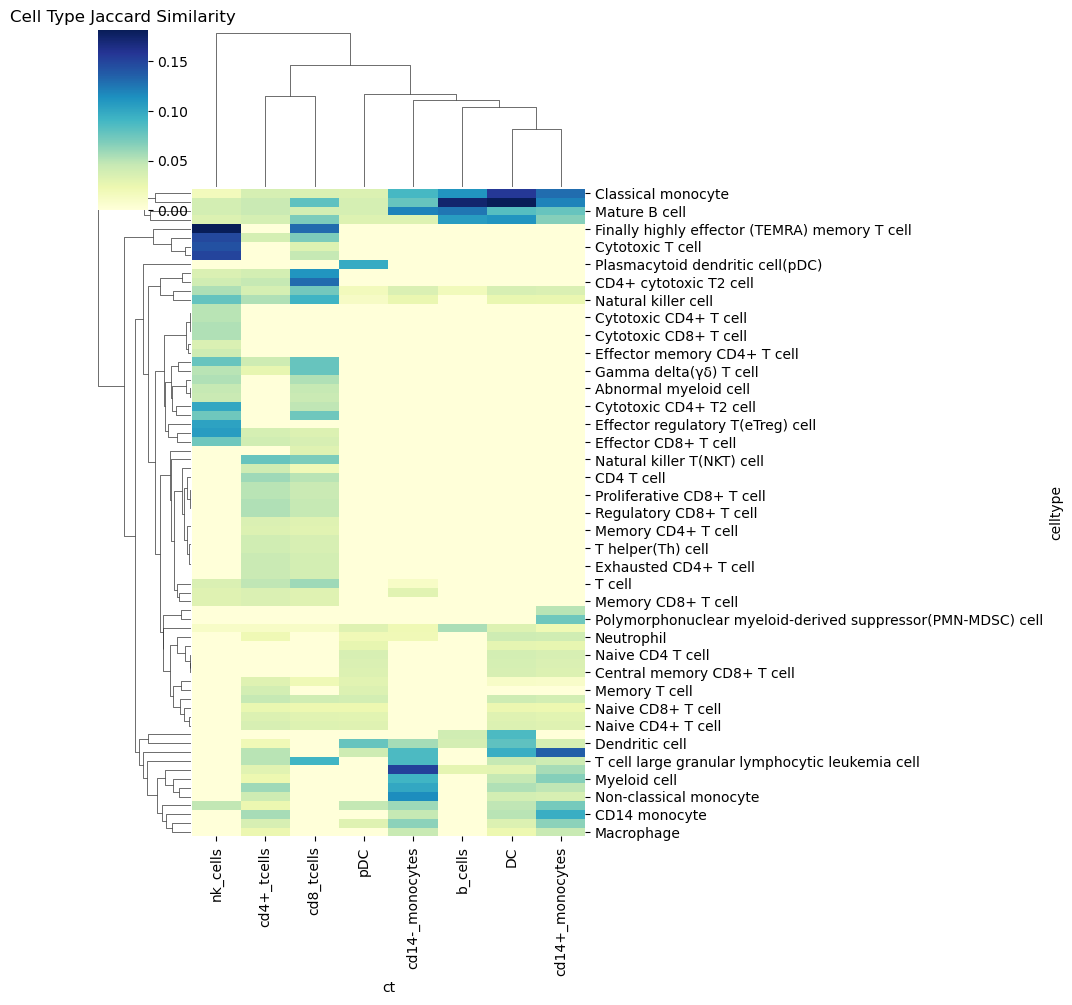

In [ ]:
matrix = jaccards[jaccards.jaccard>0].pivot(index='celltype', columns='ct', values='jaccard')

# 2. Fill NaNs (if only half the matrix is provided) and ensure symmetry
matrix = matrix.fillna(0)
full_matrix = matrix + matrix.T
#np.fill_diagonal(full_matrix, 1) # Jaccard of a cell type with itself is 1

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.clustermap(matrix, annot=False, cmap='YlGnBu', fmt=".2f")
plt.title('Cell Type Jaccard Similarity')
plt.show()

<Axes: title={'center': 'jaccard'}, xlabel='[celltype]'>

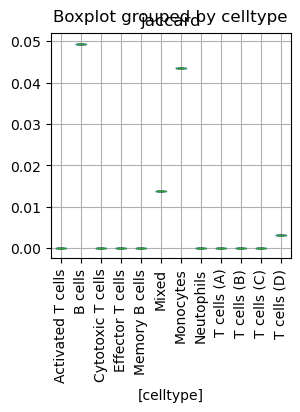

In [ ]:

jaccards[jaccards.ct == 'b_cells'].boxplot(by='celltype', rot=90, figsize=(3,3))

In [ ]:
from scipy.cluster.hierarchy import fcluster

# 1. Extract the 2 top-level clusters
# 't=2' specifies the number of clusters
# 'criterion='maxclust'' ensures we get exactly 2 groups
cluster_labels = fcluster(Z, t=2, criterion='maxclust')

# 2. Map labels back to cell names
cluster_mapping = pd.DataFrame({
    'cell_name': names,
    'cluster_id': cluster_labels
})

# 3. View the groups
group_1 = cluster_mapping[cluster_mapping['cluster_id'] == 1]['cell_name'].tolist()
group_2 = cluster_mapping[cluster_mapping['cluster_id'] == 2]['cell_name'].tolist()

print(f"Group 1: {group_1}")
print(f"Group 2: {group_2}")

ValueError: All arrays must be of the same length

In [ ]:
df, Z = get_hierarchical_clustering_from_sim(sim_matrix, names)
plot_scatter_plot(df)
cutoff = compute_regression(df, 1.4, dist_linkage = Z, correlation_threshold=0.2)

In [ ]:
from statsmodels.formula.api import quantreg
from scipy.cluster import hierarchy

clusters = hierarchy.fcluster(Z, t=1.2, criterion='distance')
dfclu = pd.DataFrame({'index':names, 'cluster' : clusters})
dfclu = dfclu.set_index('index')


,index,cluster
21,Cytotoxic CD4+ T cell,6
22,Cytotoxic CD4+ T2 cell,6
23,Cytotoxic CD8 T cell,6
71,Terminal effector CD8+ T cell,6


In [ ]:
# 1. Prepare Data & Compute Jaccard Index
# Grouping markers into sets per cell type
cm = cellmarker[(cellmarker.tissue_type.isin(['Peripheral blood', 'Blood'])) & (cellmarker.species.isin(['Human']))]
marker_sets = cm.groupby('cell_name')['marker'].apply(set).to_dict()
names = list(marker_sets.keys())

topg = set(bcrank[0:20].gene)

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Create similarity matrix
n = len(names)
sim_liste = {}

for j in marker_sets:
    sim_liste[j] = jaccard_similarity(topg, marker_sets[j])

In [ ]:
sim_liste

,celltype,jaccard
0,Activated T cells,0.000000
1,B cells,0.005263
2,Cytotoxic T cells,0.150000
3,Effector T cells,0.000000
4,Memory B cells,0.000000
5,Mixed,0.006849
6,Monocytes,0.030675
7,Neutophils,0.000000
8,T cells (A),0.035714
9,T cells (B),0.000000


In [ ]:
dfclu[dfclu.cluster==10]

,index,cluster
3,CD3/CD28-stimulated NK cell,10
11,CD56+ natural killer cell,10
24,Cytotoxic CD8+ T cell,10
30,Effector CD8 T cell,10
36,Effector regulatory T(eTreg) cell,10
39,Finally highly effector (TEMRA) memory T cell,10
41,Lymphocyte,10


<Axes: title={'center': 'jaccard'}, xlabel='[celltype]'>

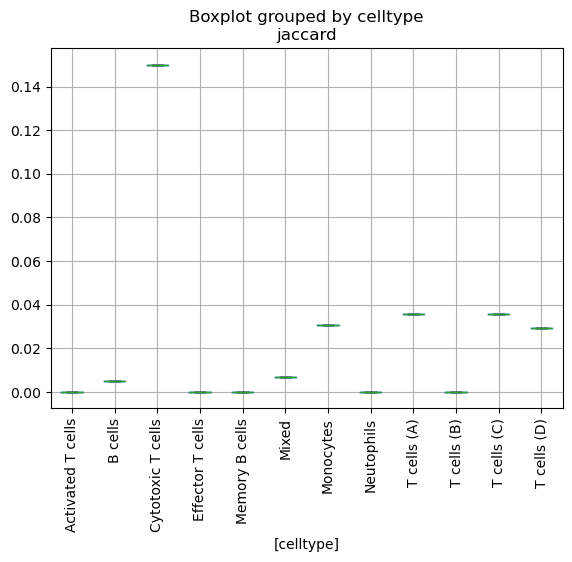

In [ ]:
for clu in dfclu.cluster.unique():
    for ct in dfclu[dfclu.cluster == clu].index:
        print(ct)

Activated CD4+ T cell
CD4+ central memory like T (Tcm-like) cell
CD4+ cytotoxic T1 cell
CD4+ cytotoxic T2 cell
Naive CD4+ T cell
Naive CD8+ T cell
Activated CD8+ T cell
CD4+ T cell
CD4+ recently activated effector memory or effector T cell (CTL)
CD8+ T cell
CD8+ mucosal-associated invariant T cell(CD8+ MAIT)
CD8+ recently activated effector memory or effector T cell (CTL)
Cytotoxic T cell
Effector CD4+ T cell
Effector CD8+ T cell
Gamma delta(γδ) T cell
Memory CD8 T cell
Memory CD8+ T cell
Natural killer T(NKT) cell
Natural killer cell
T cell
Activated T cell
CD8+ terminally differentiated effector memory re-expressing CD45RA T cell(CD8+ TEMRA)
Early activated CD4+ T cell
Early activated CD8+ T cell
Lymphoid cell
Pan-T cell
Proliferative T cell
Revertant memory CD8+ T(TEMRA) cell
T follicular helper(Tfh) cell
T helper 9(Th9) cell
CD3/CD28-stimulated NK cell
CD56+ natural killer cell
Cytotoxic CD8+ T cell
Effector CD8 T cell
Effector regulatory T(eTreg) cell
Finally highly effector (TEMR

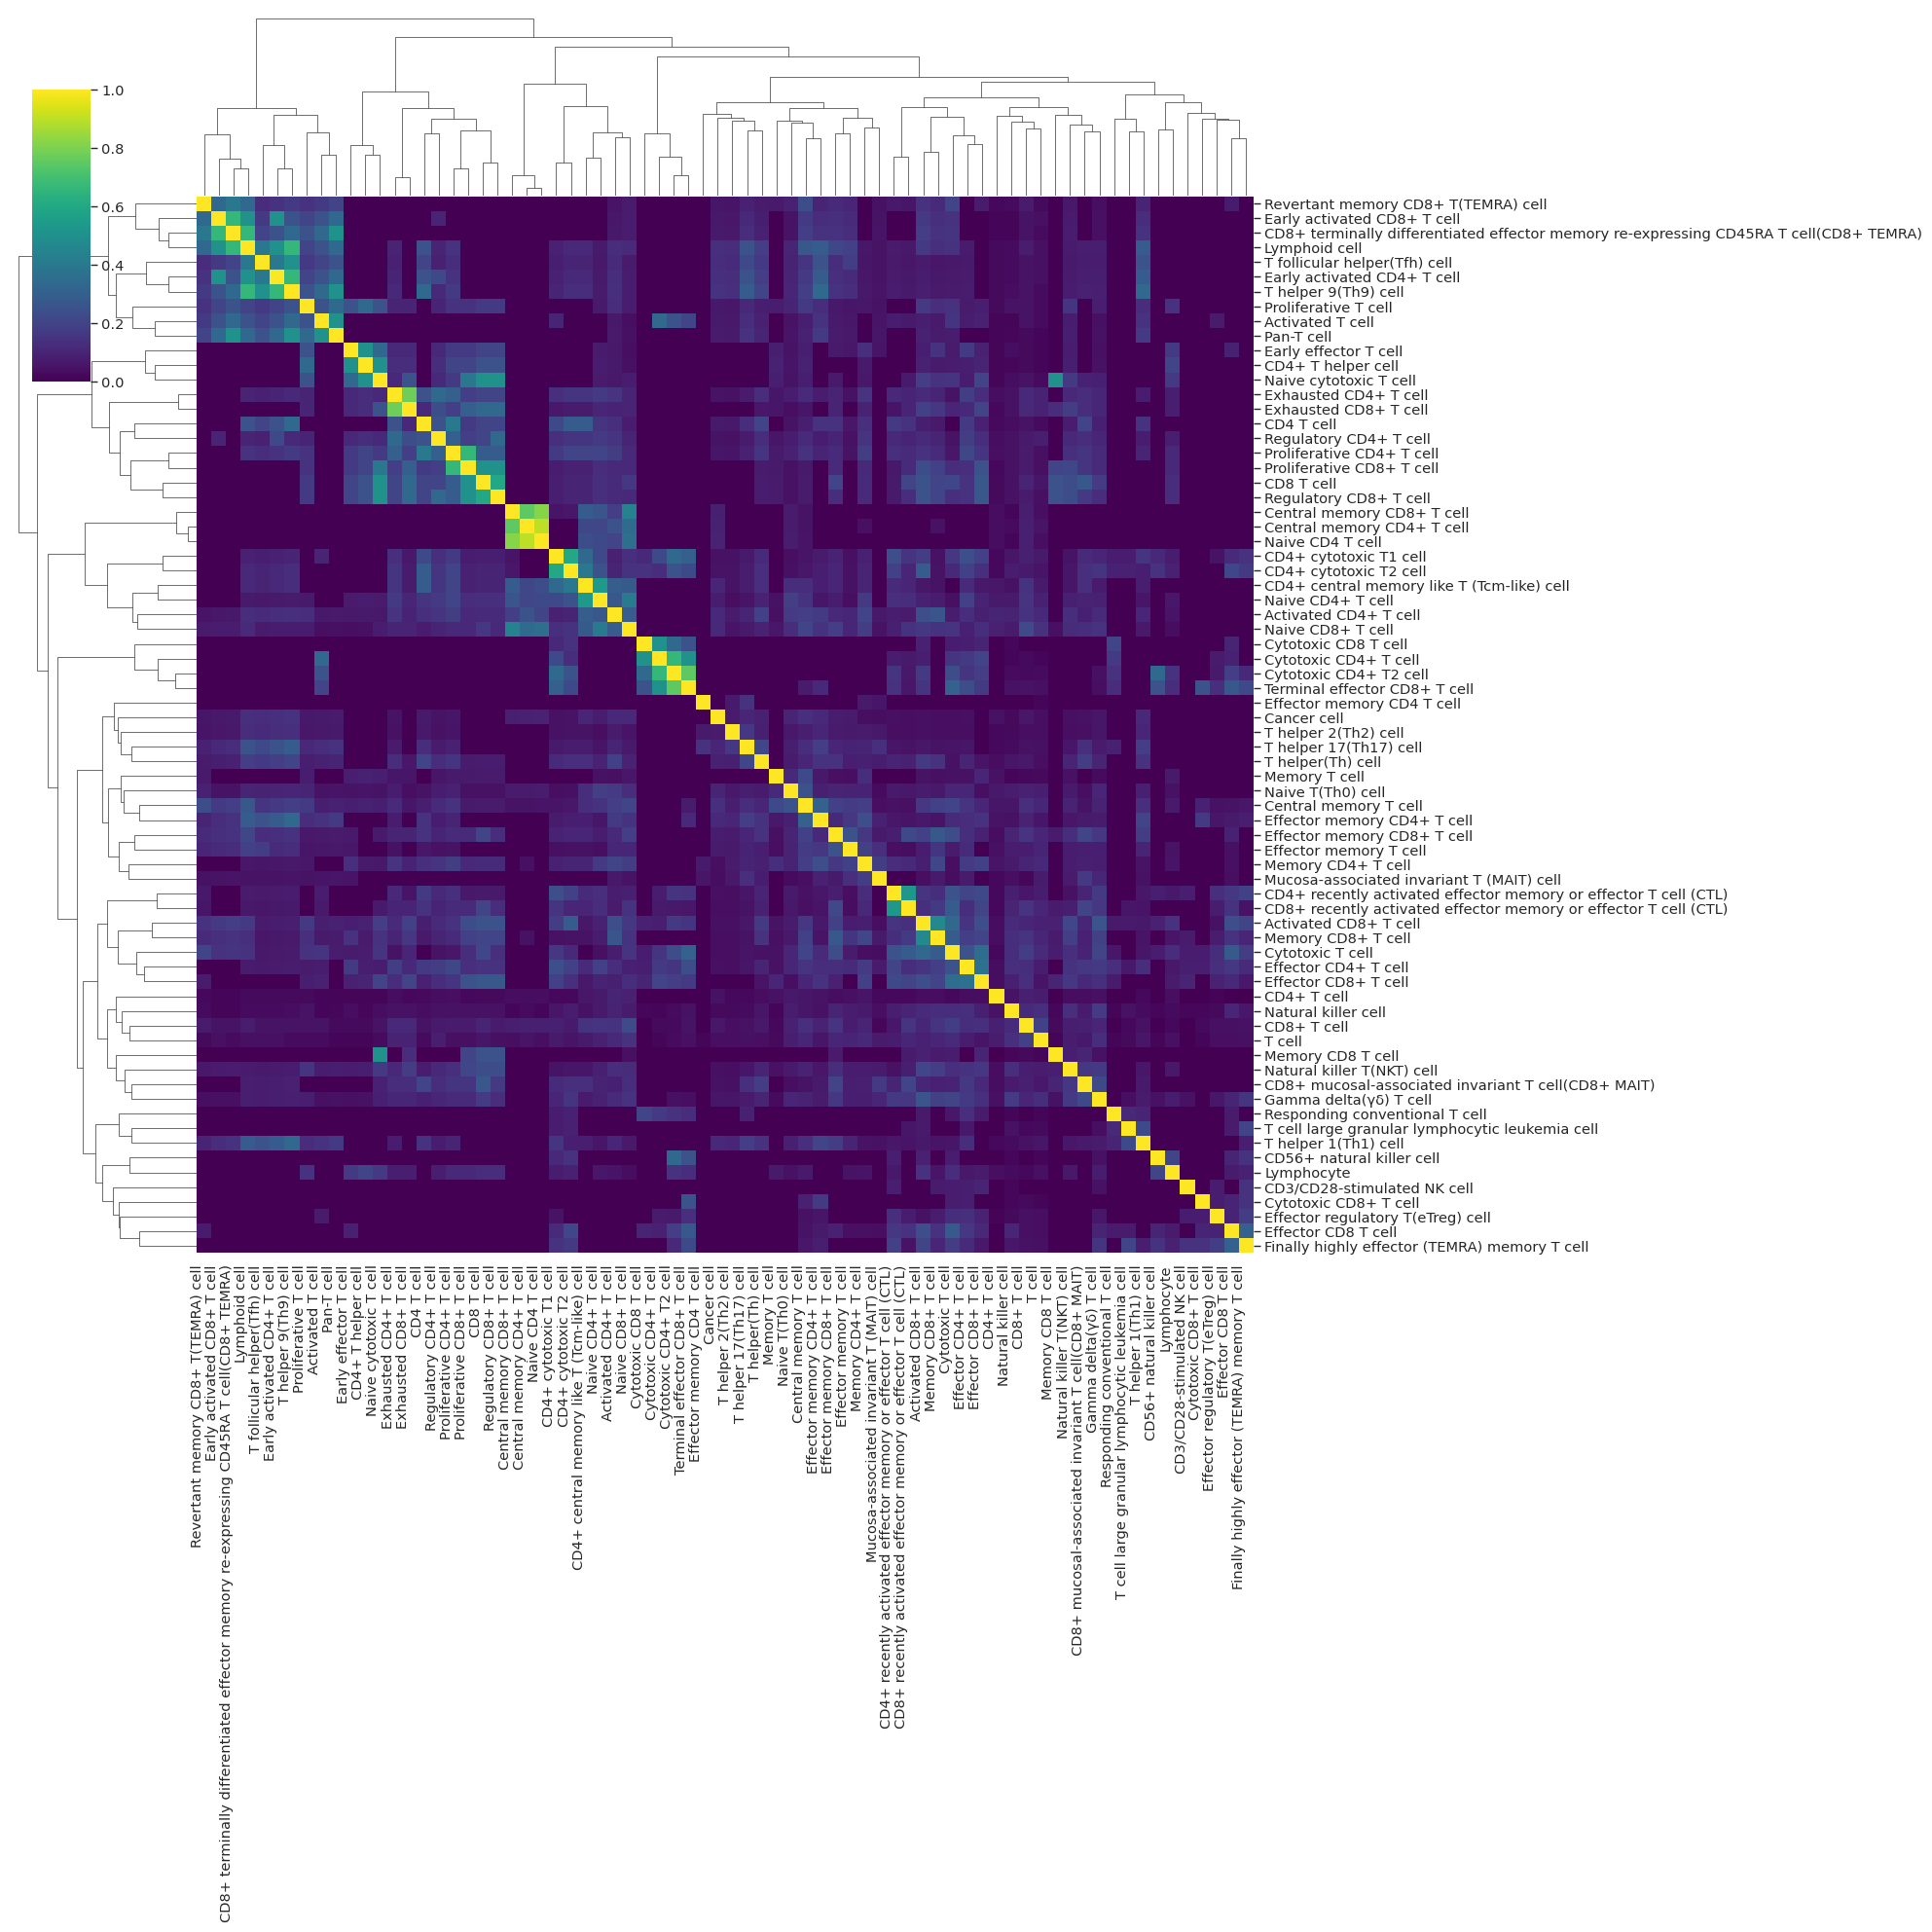

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Prepare Data & Compute Jaccard Index
# Grouping markers into sets per cell type
cm = cellmarker[(cellmarker.tissue_type.isin(['Peripheral blood', 'Blood'])) & (cellmarker.species.isin(['Human'])) & (cellmarker.cell_name.isin(group_2))]
marker_sets = cm.groupby('cell_name')['marker'].apply(set).to_dict()
names = list(marker_sets.keys())

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Create similarity matrix
n = len(names)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = jaccard_similarity(marker_sets[names[i]], marker_sets[names[j]])

# 2. Compute Clustering
# Convert similarity to distance: Distance = 1 - Similarity
dist_matrix = 1 - sim_matrix
# Ensure it's a condensed distance matrix for scipy
condensed_dist = pdist(dist_matrix) # or use squareform if matrix is already distance-based
Z = linkage(squareform(dist_matrix), method='ward')

# 3. Show Heatmap with Dendrogram
df_sim = pd.DataFrame(sim_matrix, index=names, columns=names)
# Set aesthetic parameters for better readability
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.2)

# Create the clustermap
g = sns.clustermap(
    df_sim, 
    row_linkage=Z, 
    col_linkage=Z, 
    cmap='viridis',
    figsize=(20 ,20),      # Increased size for better spacing
    xticklabels=True,      # Ensure all labels are shown
    yticklabels=True,
    dendrogram_ratio=0.15, # Shrink dendrogram to give more room to the heatmap
    cbar_pos=(0.02, 0.8, 0.03, 0.15) # Move colorbar to avoid overlapping labels
)

# Rotate labels to prevent overlapping
plt.setp(g.ax_heatmap.get_xticklabels(), ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

In [ ]:
keep_edges['unique']['DC']['summary'][50:100]

,source,count
22,IGF2BP2,30
33,F13A1,30
254,FBXL17,30
101,COMMD1,30
106,GPR183,30
104,CASK,30
216,NIBAN1,30
214,SLC9A9,30
127,CCDC88A,30
110,FCER1A,30


In [ ]:
re = keep_edges['unique']['cd14+_monocytes']['edges']
gene = 'RBP7'
re_sub = re[re.source == gene]
edges = re_sub.source + '_' + re_sub.target 

In [ ]:
re = keep_edges['unique']['cd4+_tcells']['edges']
gene = 'RPS19'
re_sub = re[re.source == gene]
edges = re_sub.source + '_' + re_sub.target

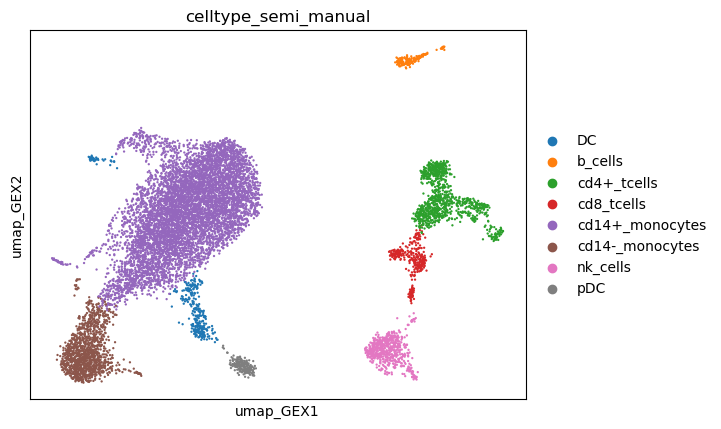

In [ ]:
#grn_adata3.layers['masked_data'] = np.multiply(grn_adata3.layers['mask'], grn_adata3.X)
grn_adata3.obsm['umap_GEX'] = adata_raw.obsm['X_umap']
sc.pl.embedding(grn_adata3, color = list(edges)+['celltype_semi_manual'], basis='umap_GEX')

KeyError: 'Could not find key RPS19 in .var_names or .obs.columns.'

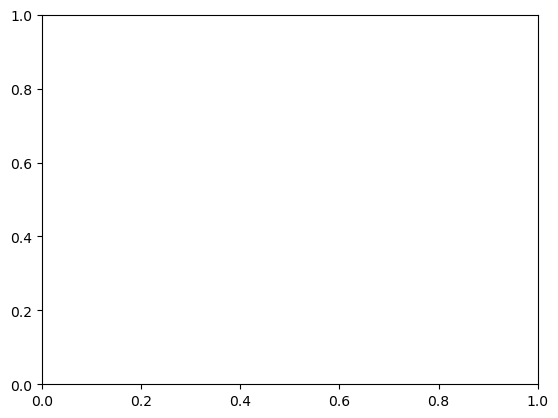

In [ ]:
sc.pl.umap(adata_raw, color = [gene]+list(re_sub.target))

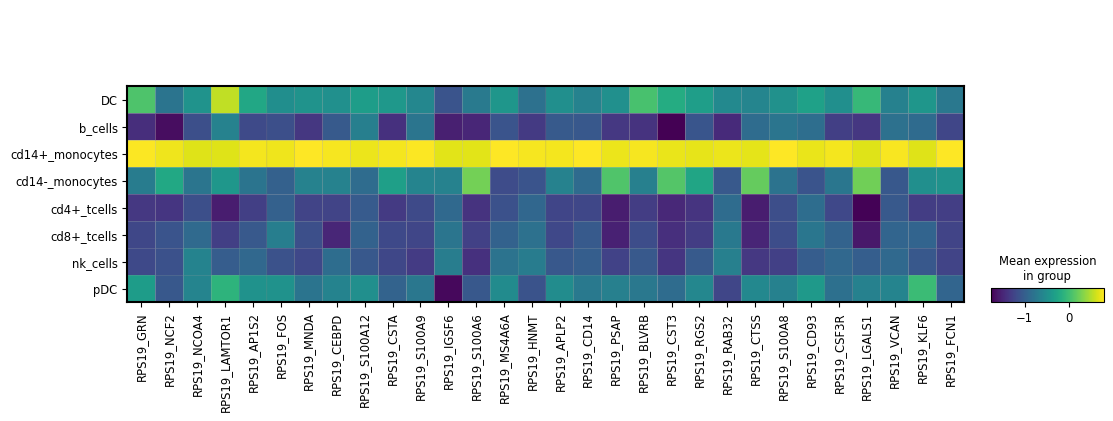

In [ ]:
sc.pl.matrixplot(grn_adata3,  list(edges), groupby='leiden_remap')

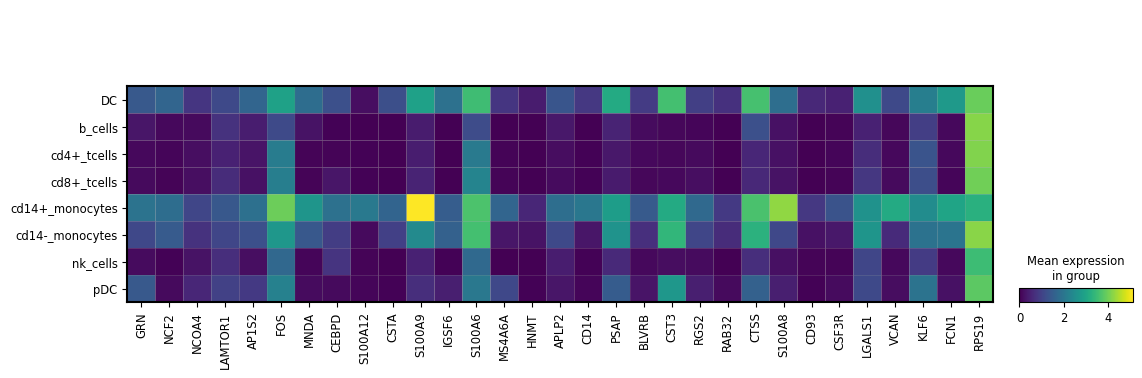

In [ ]:
sc.pl.matrixplot(adata_raw, list(re_sub.target)+[gene], groupby='celltype_semi_manual' )

In [ ]:
dff = sc.get.rank_genes_groups_df(adata_raw, group = 'cd14+_monocytes', key='wilcoxon')
dff[dff.names.str.startswith(("RPS", "RPL"))]

,names,scores,logfoldchanges,pvals,pvals_adj
462,RPS6KA5,-1.181993,-0.325703,2.372083e-01,2.706030e-01
956,RPL13,-21.690722,-0.395792,2.510213e-104,1.525552e-103
998,RPS12,-30.475519,-0.597721,5.501034e-204,6.455812e-203
1003,RPS18,-31.942188,-0.732257,6.935408e-224,9.317173e-223
1005,RPS15A,-34.993374,-0.640066,2.837660e-268,4.598811e-267
1006,RPSA,-35.199284,-1.581671,2.050760e-271,3.377139e-270
1008,RPS4X,-36.782524,-0.710438,3.513366e-296,6.522086e-295
1010,RPL3,-41.439777,-1.252608,0.000000e+00,0.000000e+00
1011,RPS5,-42.679569,-1.088508,0.000000e+00,0.000000e+00
1012,RPS3,-42.790997,-0.939436,0.000000e+00,0.000000e+00


In [ ]:
# Plot a single regulon network
# Purpose:
#   Visualize the regulatory network associated with a specific
#   transcription factor (here: CEBPA). The plot typically includes
#   the source regulator and its top downstream targets, allowing
#   inspection of connectivity, target density, and regulatory structure.

os.makedirs('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/networks')
plot_reg(grn_adata3, regulon=["RASA2"], out_path='/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/')

FileExistsError: [Errno 17] File exists: '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/networks'

In [ ]:
panaglao = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/panglaodb_human.csv')

In [ ]:
panaglao[panaglao['Official gene symbol'] == 'RBP7']

,Species,Official gene symbol,Product type,Product description,UI
4973,Homo sapiens,RBP7,protein-coding gene,retinol binding protein 7,0.005


In [ ]:
panaglao.iloc[np.where(panaglao['Product description'].str.contains('mitochon').values)[0]][0:50]

,Species,Official gene symbol,Product type,Product description,UI
2,Homo sapiens,MT-RNR2,non-coding RNA,mitochondrially encoded 16S RNA,0.183
3,Homo sapiens,MT-CO3,protein-coding gene,mitochondrially encoded cytochrome c oxidase III,0.182
5,Homo sapiens,MT-CO1,protein-coding gene,mitochondrially encoded cytochrome c oxidase I,0.181
6,Homo sapiens,MT-CO2,protein-coding gene,mitochondrially encoded cytochrome c oxidase II,0.181
19,Homo sapiens,MT-ND4,protein-coding gene,mitochondrially encoded NADH:ubiquinone oxidor...,0.179
34,Homo sapiens,MT-CYB,protein-coding gene,mitochondrially encoded cytochrome b,0.176
41,Homo sapiens,MT-ND2,protein-coding gene,mitochondrially encoded NADH:ubiquinone oxidor...,0.175
45,Homo sapiens,MT-ATP6,protein-coding gene,mitochondrially encoded ATP synthase membrane ...,0.174
49,Homo sapiens,MT-ND1,protein-coding gene,mitochondrially encoded NADH:ubiquinone oxidor...,0.173
88,Homo sapiens,ATP5E,protein coding gene,"ATP synthase, H+ transporting, mitochondrial F...",0.166


In [ ]:
panaglao[panaglao.UI<0.166]

,Species,Official gene symbol,Product type,Product description,UI
92,Homo sapiens,BTF3,protein-coding gene,basic transcription factor 3,0.165
93,Homo sapiens,RPL23,protein-coding gene,ribosomal protein L23,0.165
94,Homo sapiens,RPSA,protein-coding gene,ribosomal protein SA,0.165
95,Homo sapiens,MT-ND5,protein-coding gene,mitochondrially encoded NADH:ubiquinone oxidor...,0.164
96,Homo sapiens,RPL26,protein-coding gene,ribosomal protein L26,0.164
...,...,...,...,...,...
19299,Homo sapiens,LINC01709,non-coding RNA,long intergenic non-protein coding RNA 1709,0.000
19300,Homo sapiens,LINC01743,non-coding RNA,long intergenic non-protein coding RNA 1743,0.000
19301,Homo sapiens,LINC01744,non-coding RNA,long intergenic non-protein coding RNA 1744,0.000
19302,Homo sapiens,LINC01747,non-coding RNA,long intergenic non-protein coding RNA 1747,0.000
